In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/ecommerce_master_dataset.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12


In [3]:
df.shape

(118434, 33)

In [4]:
total_revenue = df["payment_value"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 20470726.659999996


In [5]:
df["payment_value"].mean()

np.float64(172.8493946686256)

In [6]:
top_categories = df.groupby("product_category_name")["payment_value"].sum().sort_values(ascending=False)

top_categories.head(10)

product_category_name
cama_mesa_banho           1712553.67
beleza_saude              1657373.12
informatica_acessorios    1585330.45
moveis_decoracao          1430176.39
relogios_presentes        1429216.68
esporte_lazer             1392127.56
utilidades_domesticas     1094758.13
automotivo                 852294.33
ferramentas_jardim         838280.75
cool_stuff                 779698.00
Name: payment_value, dtype: float64

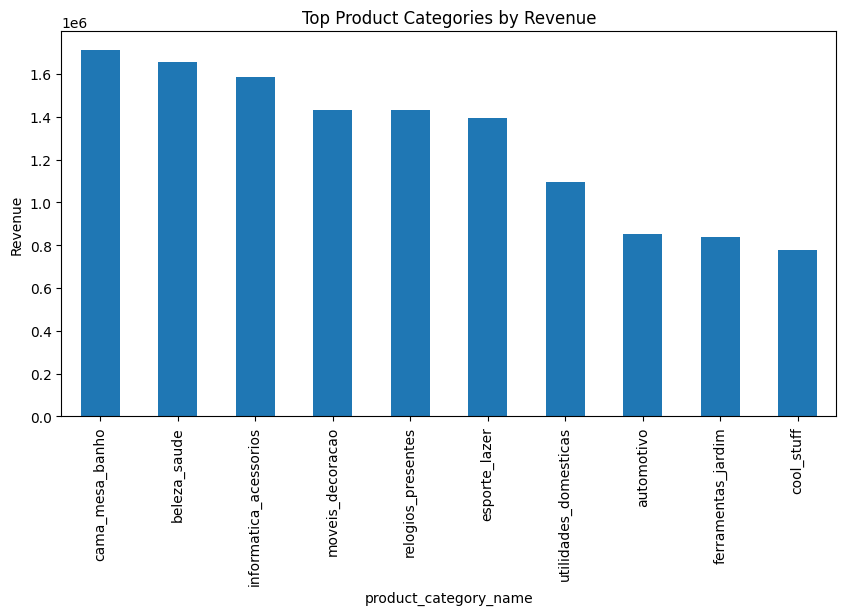

In [7]:
top_categories.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top Product Categories by Revenue")
plt.ylabel("Revenue")
plt.show()

In [8]:
top_sellers = df.groupby("seller_id")["payment_value"].sum().sort_values(ascending=False)

top_sellers.head(10)

seller_id
7c67e1448b00f6e969d365cea6b010ab    507166.91
1025f0e2d44d7041d6cf58b6550e0bfa    308222.04
4a3ca9315b744ce9f8e9374361493884    301245.27
1f50f920176fa81dab994f9023523100    290253.42
53243585a1d6dc2643021fd1853d8905    284903.08
da8622b14eb17ae2831f4ac5b9dab84a    272219.32
4869f7a5dfa277a7dca6462dcf3b52b2    264166.12
955fee9216a65b617aa5c0531780ce60    236322.30
fa1c13f2614d7b5c4749cbc52fecda94    206513.23
7e93a43ef30c4f03f38b393420bc753a    185134.21
Name: payment_value, dtype: float64

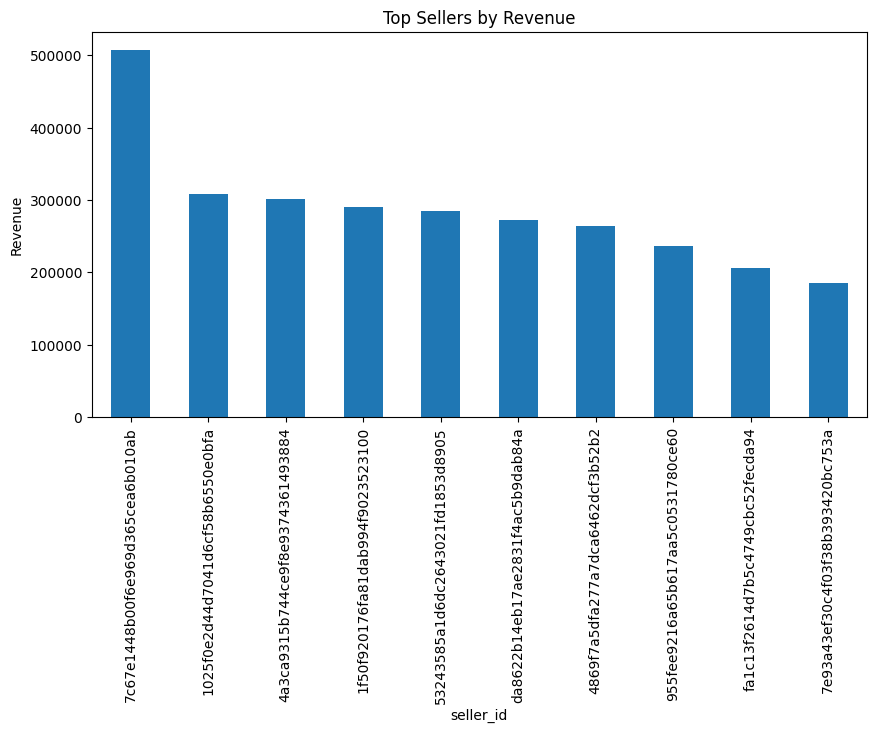

In [9]:
top_sellers.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top Sellers by Revenue")
plt.ylabel("Revenue")
plt.show()

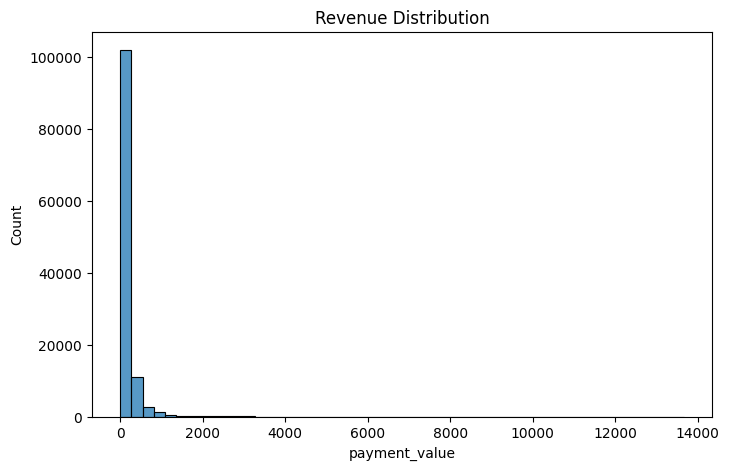

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["payment_value"], bins=50)

plt.title("Revenue Distribution")
plt.show()